# Forest Fire Prevention Follow-Up Analysis

This notebook performs probability estimation, feature engineering, feature distribution analysis, and normal distribution fitting for the **Montesinho Natural Park** wildfires dataset.

In [1]:
# Cell 2: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Configure visual styling
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Dataset
Loading data from the `data` folder relative to the `notebooks` directory.

In [2]:
# Cell 4: Auto-detect dataset path and load 'df'
import os
import pandas as pd

file_name = 'C2M2_GradedLab_Forest_fire_prevention_follow_up.xlsx'
file_path = None

# Search current directory and all subdirectories for the file
for root, dirs, files in os.walk('.'):
    if file_name in files:
        file_path = os.path.join(root, file_name)
        break

# Fallback: check one directory up if searching from inside notebooks folder
if not file_path:
    for root, dirs, files in os.walk('..'):
        if file_name in files:
            file_path = os.path.join(root, file_name)
            break

if file_path:
    print(f"File found at: {os.path.abspath(file_path)}")
    df = pd.read_excel(file_path, sheet_name='Data')
    print(f"Total Records Loaded: {len(df)}")
    display(df.head())
else:
    raise FileNotFoundError(
        f"Could not find '{file_name}'. Ensure the Excel file is placed inside your project folder or data folder!"
    )

File found at: c:\Users\AVIRAJ\OneDrive\Desktop\Pyhton Project\forest-fire-prevention\data\C2M2_GradedLab_Forest_fire_prevention_follow_up.xlsx
Total Records Loaded: 517


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,is_small
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,NaN
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,NaN
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,NaN
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,NaN
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,NaN


## 2. Exercise 1 — Sample Frequencies & Probabilities
Calculating marginal and conditional probabilities for fire location ($X = 2$) and burn area ($area < 0.5\text{ ha}$).

In [3]:
# Cell 6: Calculate sample frequencies and probabilities
total_fires = len(df)

# 1. Frequency of fires at X = 2
x2_count = (df['X'] == 2).sum()
p_x2 = x2_count / total_fires

# 2. Frequency of small area fires (< 0.5 ha)
small_count = (df['area'] < 0.5).sum()
p_small = small_count / total_fires

# 3. Frequency of small area fires AND on X = 2
x2_and_small_count = ((df['X'] == 2) & (df['area'] < 0.5)).sum()
p_x2_and_small = x2_and_small_count / total_fires

# 4. Conditional Probability: P(area < 0.5 | X = 2)
p_small_given_x2 = x2_and_small_count / x2_count

# Output results
print(f"1. P(X = 2): {p_x2:.4f} ({p_x2*100:.2f}%) [{x2_count}/{total_fires}]")
print(f"2. P(area < 0.5): {p_small:.4f} ({p_small*100:.2f}%) [{small_count}/{total_fires}]")
print(f"3. P(area < 0.5 AND X = 2): {p_x2_and_small:.4f} ({p_x2_and_small*100:.2f}%) [{x2_and_small_count}/{total_fires}]")
print(f"4. P(area < 0.5 | X = 2): {p_small_given_x2:.4f} ({p_small_given_x2*100:.2f}%) [{x2_and_small_count}/{x2_count}]")

# Independence test check
p_independent_product = p_x2 * p_small
print("\n--- Independence Test ---")
print(f"P(X=2) * P(area < 0.5) = {p_independent_product:.4f}")
print(f"Actual P(X=2 AND area < 0.5) = {p_x2_and_small:.4f}")
print("Are events independent?", np.isclose(p_independent_product, p_x2_and_small))

1. P(X = 2): 0.1412 (14.12%) [73/517]
2. P(area < 0.5): 0.4971 (49.71%) [257/517]
3. P(area < 0.5 AND X = 2): 0.0619 (6.19%) [32/517]
4. P(area < 0.5 | X = 2): 0.4384 (43.84%) [32/73]

--- Independence Test ---
P(X=2) * P(area < 0.5) = 0.0702
Actual P(X=2 AND area < 0.5) = 0.0619
Are events independent? False


## 3. Exercise 2 — Feature Engineering (`is_small`)
Creating a binary feature `is_small` where $1$ indicates a burn area under $0.5\text{ ha}$ and $0$ indicates otherwise.

In [4]:
# Cell 8: Feature engineering for is_small
df['is_small'] = (df['area'] < 0.5).astype(int)

# Display value counts
print("Distribution of is_small:")
print(df['is_small'].value_counts())

Distribution of is_small:
is_small
0    260
1    257
Name: count, dtype: int64


## 4. Exercise 2 — Feature Distributions Visualization
Plotting histograms and count plots for key environmental features (`temp`, `DC`, `ISI`, `is_small`) and saving the visual export to the `visuals` folder[cite: 10].

C:\Users\AVIRAJ\AppData\Local\Temp\ipykernel_32068\3131615154.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_small', data=df, ax=axes[1, 1], palette='Set2')


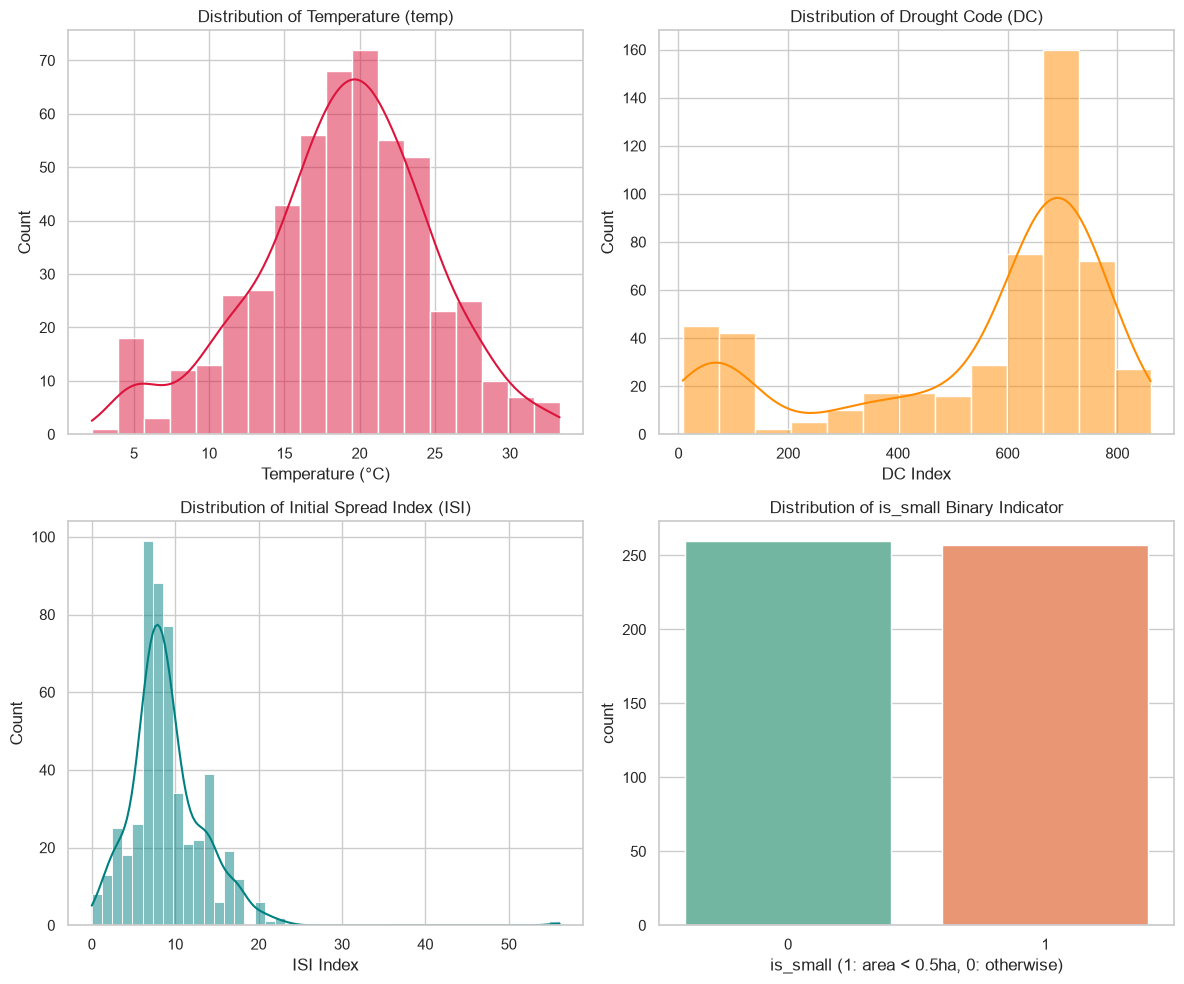

Visualization saved to ../visuals/forest_fire_distributions.png


<Figure size 640x480 with 0 Axes>

Visualization saved successfully to ../visuals/forest_fire_distributions.png


In [5]:
# Cell 10: Create grid of distributions and export image
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Temperature
sns.histplot(df['temp'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Distribution of Temperature (temp)')
axes[0, 0].set_xlabel('Temperature (°C)')

# 2. Drought Code (DC)
sns.histplot(df['DC'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Distribution of Drought Code (DC)')
axes[0, 1].set_xlabel('DC Index')

# 3. Initial Spread Index (ISI)
sns.histplot(df['ISI'], kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Distribution of Initial Spread Index (ISI)')
axes[1, 0].set_xlabel('ISI Index')

# 4. is_small Binary Indicator
sns.countplot(x='is_small', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribution of is_small Binary Indicator')
axes[1, 1].set_xlabel('is_small (1: area < 0.5ha, 0: otherwise)')

plt.tight_layout()

# Save visual export
plt.savefig('../visuals/forest_fire_distributions.png', dpi=300)
plt.show()
print("Visualization saved to ../visuals/forest_fire_distributions.png")

# Save visual export safely
output_dir = '../visuals' if os.path.exists('../visuals') else 'visuals'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'forest_fire_distributions.png'), dpi=300)

plt.show()
print(f"Visualization saved successfully to {output_dir}/forest_fire_distributions.png")

## 5. Exercise 3 — Normal Distribution Analysis (`temp`)
Testing the sample mean ($\bar{x}$) and sample standard deviation ($s$) against the **Empirical Rule (68–95–99.7)**.

# Cell 12: Empirical rule validation for temperature
temp_mean = df['temp'].mean()
temp_std = df['temp'].std()

print(f"Sample Mean (x̄): {temp_mean:.4f}°C")
print(f"Sample Standard Deviation (s): {temp_std:.4f}")

# Proportions within standard deviation bounds
within_1s = ((df['temp'] >= temp_mean - temp_std) & (df['temp'] <= temp_mean + temp_std)).mean()
within_2s = ((df['temp'] >= temp_mean - 2*temp_std) & (df['temp'] <= temp_mean + 2*temp_std)).mean()
within_3s = ((df['temp'] >= temp_mean - 3*temp_std) & (df['temp'] <= temp_mean + 3*temp_std)).mean()

print("\n--- Empirical Rule Comparison ---")
print(f"Within 1 Std Dev (x̄ ± 1s): {within_1s*100:.2f}% (Target: ~68%)")
print(f"Within 2 Std Devs (x̄ ± 2s): {within_2s*100:.2f}% (Target: ~95%)")
print(f"Within 3 Std Devs (x̄ ± 3s): {within_3s*100:.2f}% (Target: ~99.7%)")